<a href="https://colab.research.google.com/github/varshabantu/Bglr_House_Price_Prediction/blob/main/Ecommerce_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Ecommerce Sales Drop

**Company scenario(Flipkart/Amazon):**

we are seeing drop in revenue find the reason and suggest actions.

In [ ]:
#import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the DATA
customers=pd.read_csv('customers.csv')
orders=pd.read_csv('orders.csv')
products=pd.read_csv('products.csv')

# EDA

In [ ]:
#merging the tables using joins
df=pd.merge(customers,orders,on="customer_id",how="inner")
df=pd.merge(df,products,on="product_id",how="inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#Converting date columns into datetime format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
#creating revenue column
#formula: revenue=price*quality
df["revenue"]=df["price"]*df["quantity"]
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


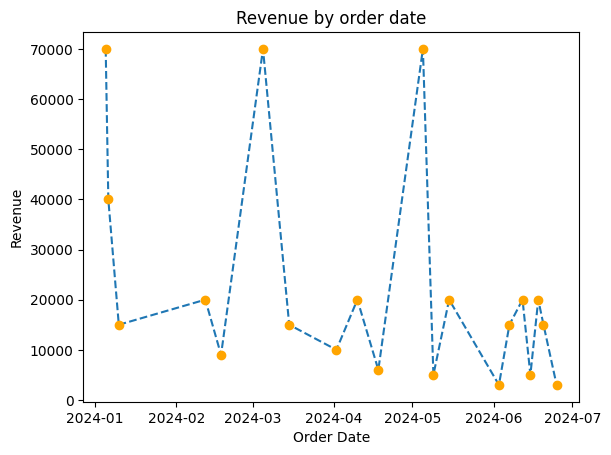

In [ ]:
#Revenue trend
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",linestyle="--",mfc="orange",mec="orange")
plt.xlabel("Order Date")
plt.ylabel("Revenue")
plt.title("Revenue by order date")
plt.show()

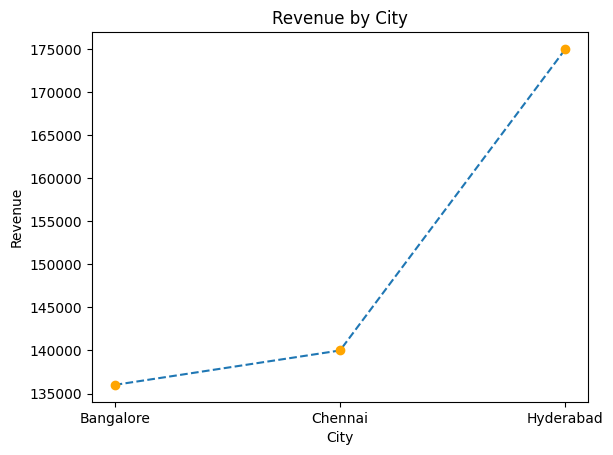

In [ ]:
#Revenue trend
df["city"].unique()
#to check in which city the drop has happend

revenue=df.groupby("city")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["city"],revenue["revenue"],marker="o",linestyle="--",mfc="orange",mec="orange")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.show()

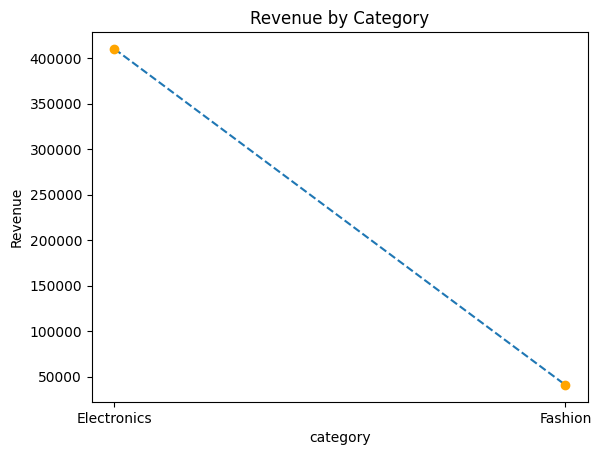

In [ ]:
#Revenue trend by category
df["category"].unique()
#to check in which category the drop has happend

revenue=df.groupby("category")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index() #covert series to dataframe
plt.plot(revenue["category"],revenue["revenue"],marker="o",linestyle="--",mfc="orange",mec="orange")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue by Category")
plt.show()

In [ ]:
#count customers based on order_id
customer_count=df.groupby("customer_id")["order_id"].count()
customer_count

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


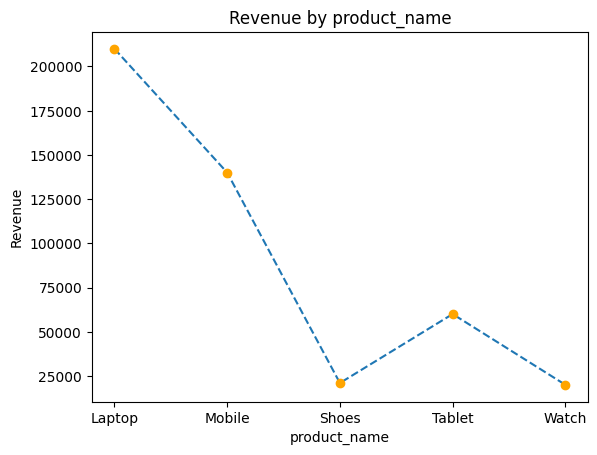

In [ ]:
#Revenue trend for product_name
#check which product sold less
# product_count=df.groupby("product_id")["order_id"].count()
# product_count
#Revenue trend
df["product_name"].unique()
revenue=df.groupby("product_name")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["revenue"],marker="o",linestyle="--",mfc="orange",mec="orange")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue by product_name")
plt.show()


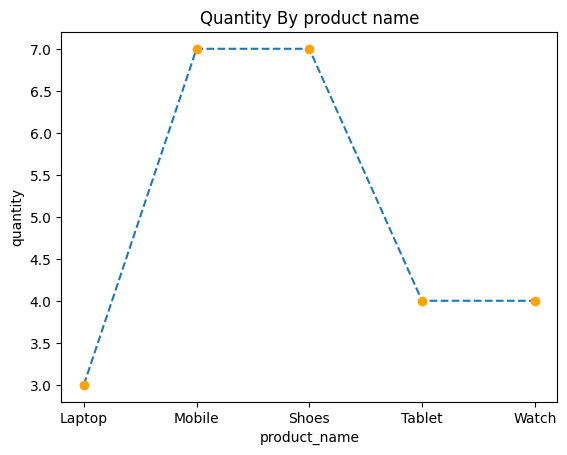

In [ ]:
df["product_name"].unique()
revenue=df.groupby("product_name")["quantity"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"],revenue["quantity"],marker="o",linestyle="--",mfc="orange",mec="orange")
plt.xlabel("product_name")
plt.ylabel("quantity")
plt.title("Quantity By product name")
plt.show()

# Insights:
1. Revenue got dropped in last two months(june,july)
2. Bangalore contibuted more in revenue drop
3. Fashion category recorded less revenue
4. Repeated customers ordered less
5. Shoe and Watch sales declines significantly

# Recommendation
1. Marketing should be done in bangalore
2. Provide discounts for shoe and watch
3. Coupens,Discounts,Loyalty programs for repeated customers

In [ ]:
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


In [ ]:
orders.head()

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3
